In [ ]:
# Google Colab only (does nothing elsewhere): fetch the bundle next to this notebook and install pPXF.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")     # one core on Colab / Binder
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ppxf", "fitsio", "ipywidgets"], check=True)
    if not os.path.exists("interbars_students"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/EdoBorsato/INTERBARS_classes"], check=True)
    os.chdir("interbars_students/reference"); print("Colab: working in", os.getcwd())

# 1. Finding the spectra, and what a fibre spectrum is

**interbars**: barred galaxies in interacting pairs, at $z \approx 0.01$–$0.05$. This series asks whether
the gas in their **nuclei** is ionised by young stars or by an active nucleus. The data are optical
fibre spectra from public surveys (DESI, SDSS). Before measuring anything we need to know:

* which spectra exist for each galaxy, and *where exactly* on the galaxy the fibre was placed;
* how big the fibre is on the sky and in kiloparsecs at the galaxy's distance;
* what a spectrum file contains: flux units, uncertainties, the wavelength grid (pixel scale), the
  **spectral resolution** (how blurred a narrow line becomes), and bad-pixel masks.

Each of you works on **one system** (a galaxy, a pair, or a few) through the three notebooks. You choose
it once, in section 1.2 of this notebook; notebooks 2 (line measurements with pPXF) and 3 (BPT
classification) pick it up from there. Environment: the `fastspecfit` conda env
(`source scripts/fastspecfit_env.sh`).

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):    # one BLAS thread: on Binder / Colab the pod has
    os.environ.setdefault(_v, "1")                                          # one core and multi-threaded BLAS is 30x slower
import os, io, json, sys
from pathlib import Path
import numpy as np, pandas as pd, fitsio, requests
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.wcs import WCS
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "dataset").is_dir())   # the course folder
sys.path.insert(0, str(ROOT / "scripts"))
os.environ.setdefault("DESI_SPECTRO_REDUX", str(ROOT / "output" / "desi_redux"))
import run_ppxf as RP                      # the project's spectrum inventory and readers (DESI and SDSS)
CACHE = ROOT / "output" / "notebooks"; CACHE.mkdir(parents=True, exist_ok=True)
CFG = ROOT / "reference" / "my_systems.json"          # the systems chosen here are read by notebooks 2 and 3
C_KMS = 299792.458
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
STAGE = {0: "pre-interaction", 1: "merger", 2: "post-merger"}
plt.rcParams.update({"figure.dpi": 110})
targets = pd.read_csv(ROOT / "dataset/catalogs/interbars_targets.csv").set_index("system")
specz = pd.read_csv(ROOT / "dataset/catalogs/interbars_specz.csv").set_index("system")
inventory = RP.targets().set_index("label")           # every DESI / SDSS spectrum of the sample

def desi_row(coadd, targetid):
    # the FIBERMAP row and the three arms (wave, flux, ivar, mask, resolution) of one DESI spectrum
    fm = fitsio.read(coadd, "FIBERMAP"); i = int(np.where(fm["TARGETID"] == int(targetid))[0][0]); arms = {}
    with fitsio.FITS(coadd) as F:
        for b in "BRZ":
            arms[b] = dict(wave=F[f"{b}_WAVELENGTH"].read(), flux=F[f"{b}_FLUX"][i:i + 1, :][0], ivar=F[f"{b}_IVAR"][i:i + 1, :][0],
                           mask=F[f"{b}_MASK"][i:i + 1, :][0], res=F[f"{b}_RESOLUTION"][i:i + 1, :, :][0])
    return fm[i], arms

def sdss_file(path):
    # header, COADD table and SPECOBJ row of an SDSS lite file (BOSS-era files carry unnamed HDUs)
    with fitsio.FITS(path) as F:
        names = [h.get_extname() for h in F]
        return F[0].read_header(), F[names.index("COADD") if "COADD" in names else 1].read(), F[names.index("SPECOBJ") if "SPECOBJ" in names else 2].read()[0]

def ls_cutout(ra, dec, size_arcsec, pixscale=0.262, layer="ls-dr10"):
    # Legacy Survey colour JPEG + a WCS built from the request (TAN projection, north up, east left)
    npix = int(round(size_arcsec / pixscale)); f = CACHE / f"ls_{ra:.5f}_{dec:.5f}_{size_arcsec:.0f}_{pixscale}.jpg"
    if not f.exists():
        r = requests.get("https://www.legacysurvey.org/viewer/jpeg-cutout", params=dict(ra=ra, dec=dec, layer=layer, pixscale=pixscale, size=npix), timeout=120)
        r.raise_for_status(); f.write_bytes(r.content)
    im = np.flipud(np.asarray(Image.open(f)))
    w = WCS(naxis=2); w.wcs.ctype = ["RA---TAN", "DEC--TAN"]; w.wcs.crval = [ra, dec]
    w.wcs.crpix = [(im.shape[1] + 1) / 2, (im.shape[0] + 1) / 2]; w.wcs.cdelt = [-pixscale / 3600, pixscale / 3600]
    return im, w
print("repo:", ROOT)

repo: /home/eborsato/PyAutoThings/workspace/interbars


## 1.1 The sample

One row per system: the main galaxy, its position (resolved through SIMBAD and checked on the images),
the redshift, the interaction stage from the visual classification (`class_VC`: 0 = pre-interaction,
1 = merger, 2 = post-merger), and a named companion where there is one.

In [2]:
cols = ["ra", "dec", "z_hand", "class_EB", "class_VC", "comp_name", "comp_z_hand"]
print(targets[cols].round(5).to_string())

                               ra       dec   z_hand  class_EB  class_VC                 comp_name  comp_z_hand
system                                                                                                         
LEDA181851              147.89718   0.43474  0.02066       2.0       2.0                       NaN          NaN
2MASXJ09551395+1417576  148.80812  14.29927  0.02421       2.0       0.0                 PGC028602      0.02443
IC3378                  187.00649  17.29646  0.04528       0.0       0.0                    IC3379      0.04521
2MASXJ11422226+0845548  175.59291   8.76548  0.02194       1.0       1.0                    IC0720      0.02161
NVSSJ084256+133826      130.73492  13.64160  0.01681       1.0       1.0  [WGB2006] 084012+13500 b      0.01631
IC2810                  171.43770  14.67662  0.03400       0.0       0.0                   IC2810B      0.03390
Z44-80                  201.04014   5.25978  0.02487       2.0       2.0                       NaN      

## 1.2 Choose your system

Set `MY_SYSTEMS` to one or more names of the table above. The choice is saved to
`reference/my_systems.json` and read by the other notebooks. The card below lists what the archives
hold for it: every DESI and SDSS spectrum of the main galaxy and of its companion.

In [3]:
MY_SYSTEMS = ["IC3147B"]                       # <-- set once, here; e.g. ["NGC2864"], ["MCG-01-09-041"], ["UGC6142", "Z44-80"]
CFG.write_text(json.dumps(MY_SYSTEMS)); print("saved to", CFG.relative_to(ROOT), "->", MY_SYSTEMS, "\n")
for s_ in MY_SYSTEMS:
    r = targets.loc[s_]
    print(f"{s_}: RA {r.ra:.5f} Dec {r.dec:.5f}, z = {r.z_hand:.4f}, VC class {r.class_VC:.0f} ({STAGE.get(r.class_VC, '?')}), EB class {r.class_EB:.0f}"
          + (f"; companion {r.comp_name} at {specz.loc[s_, 'comp_sep_kpc']:.0f} kpc, dv {specz.loc[s_, 'dv_comp_kms']:+.0f} km/s" if isinstance(r.comp_name, str) else "; no companion"))
    if isinstance(r.note, str): print("   note:", r.note)
    print(inventory[inventory.system == s_][["role", "source", "spec_id", "z_in"]].to_string())
    print()
SYSTEM = MY_SYSTEMS[0]; z = float(targets.loc[SYSTEM, "z_hand"]); ra, dec = float(targets.loc[SYSTEM, "ra"]), float(targets.loc[SYSTEM, "dec"])
kpc_per_arcsec = 1 / COSMO.arcsec_per_kpc_proper(z).value

saved to notebooks/my_systems.json -> ['IC3147B'] 

IC3147B: RA 184.82783 Dec 12.01821, z = 0.0256, VC class 1 (merger), EB class 1; companion IC3147 at 12 kpc, dv +111 km/s
   note: reduction position 15" from SIMBAD; LS reduction cutout centre off the galaxy (pair cutout centred between members?)
                   role source            spec_id      z_in
label                                                      
IC3147B            main   DESI  39628075859711056  0.025627
IC3147B_sdss       main   SDSS     1613-53115-145  0.025578
IC3147B_comp_sdss  comp   SDSS     1614-53120-312  0.025957



## 1.3 Searching the archives for spectra

Spectroscopic surveys publish **catalogues** (one row per spectrum: position, redshift, quality) that
can be queried with SQL over the web. Two are relevant here: **SDSS DR17** (2000–2020, 3″ then 2″
fibres) and **DESI DR1** (2021–2022, 1.5″ fibres), both served by the NOIRLab Astro Data Lab. The query
asks for every spectrum within 30″ of each of your galaxies. The full project search (9 surveys, 10′
around every galaxy, `dataset/catalogs/specz_matches.csv`) used exactly these queries.

In [4]:
def datalab(sql):
    r = requests.post("https://datalab.noirlab.edu/tap/sync", data=dict(REQUEST="doQuery", LANG="ADQL", FORMAT="csv", QUERY=sql), timeout=120)
    r.raise_for_status(); return pd.read_csv(io.StringIO(r.text))
R = 30 / 3600
for s_ in MY_SYSTEMS:
    ra_, dec_ = float(targets.loc[s_, "ra"]), float(targets.loc[s_, "dec"])
    box = lambda racol, deccol: f"{racol} BETWEEN {ra_ - R / np.cos(np.radians(dec_))} AND {ra_ + R / np.cos(np.radians(dec_))} AND {deccol} BETWEEN {dec_ - R} AND {dec_ + R}"
    try:
        sdss = datalab(f"SELECT specobjid, plate, mjd, fiberid, ra, dec, z, zerr, zwarning, class, survey FROM sdss_dr17.specobj WHERE {box('ra', 'dec')}")
        desi = datalab(f"SELECT targetid, mean_fiber_ra AS ra, mean_fiber_dec AS dec, z, zerr, zwarn, spectype, survey, program, healpix, zcat_primary FROM desi_dr1.zpix WHERE {box('mean_fiber_ra', 'mean_fiber_dec')}")
        for name, d in (("SDSS DR17", sdss), ("DESI DR1", desi)):
            d["sep_arcsec"] = 3600 * np.hypot((d.ra - ra_) * np.cos(np.radians(dec_)), d.dec - dec_)
            print(f"== {s_} / {name}: {len(d)} spectra within 30\""); print(d.sort_values("sep_arcsec").round(5).to_string(index=False)); print()
    except Exception as e:
        print("offline? using the project's cached search instead:", e)
        m = pd.read_csv(ROOT / "dataset/catalogs/specz_matches.csv"); print(m[(m.system == s_) & (m.sep_arcsec < 30) & m.survey.isin(["SDSS DR17", "DESI DR1"])][["survey", "obj_id", "z", "zqual", "sep_arcsec"]].to_string(index=False))

== IC3147B / SDSS DR17: 2 spectra within 30"
          specobjid  plate   mjd  fiberid        ra      dec       z    zerr  zwarning  class survey  sep_arcsec
1816116459294713856   1613 53115      145 184.82778 12.01819 0.02558 0.00002         0 GALAXY   sdss     0.18505
1817288263895902208   1614 53120      312 184.82165 12.01619 0.02596 0.00001         0 GALAXY   sdss    22.93557

== IC3147B / DESI DR1: 1 spectra within 30"
         targetid        ra      dec       z  zerr  zwarn spectype survey program  healpix zcat_primary  sep_arcsec
39628075859711056 184.82775 12.01815 0.02563   0.0      0   GALAXY   main  bright    27769            t     0.35657



Things to notice: several rows can be the *same galaxy* (DESI observes a target in several programs;
`zcat_primary` marks the best one), rows tens of arcseconds away are *other* galaxies (or the companion),
and the quality flags (`zwarning`, `zwarn`) tell whether the pipeline trusted its redshift.

## 1.4 The image, the WCS, and where the fibres sit

A **WCS** (world coordinate system) maps image pixels to sky coordinates. For a small cutout a
tangent-plane projection is enough: a reference pixel `CRPIX` at `CRVAL` (RA, Dec) and a pixel scale
`CDELT` in degrees per pixel (negative in RA: east is left). We build one for a Legacy Survey DR10
colour image (0.262″ native pixels) and draw every fibre of the system on it:

* DESI: 1.5″ diameter at `MEAN_FIBER_RA/DEC` (where the fibre actually was, averaged over exposures);
* SDSS: 3″ diameter at `PLUG_RA/DEC` (from the spectrum file header).

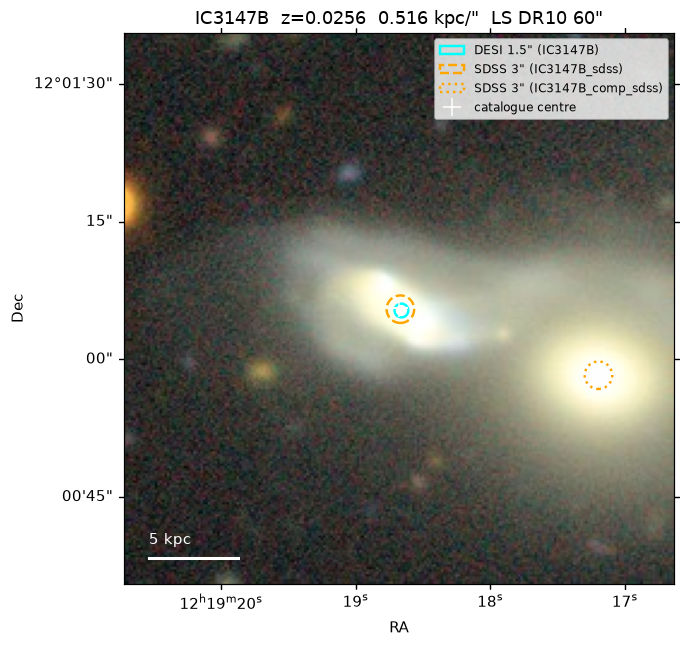

IC3147B: 1 arcsec = 0.516 kpc -> DESI fibre 1.5" = 0.77 kpc, SDSS fibre 3" = 1.55 kpc; DESI fibre / total r-band flux = 5.5%


In [5]:
FOV = 60.0
for s_ in MY_SYSTEMS:
    r = targets.loc[s_]; ra_, dec_, z_ = float(r.ra), float(r.dec), float(r.z_hand); kpc = 1 / COSMO.arcsec_per_kpc_proper(z_).value
    im, w = ls_cutout(ra_, dec_, FOV)
    fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(projection=w)); ax.imshow(im, origin="lower")
    def circle(ra_c, dec_c, diam, **kw):
        x, y = w.world_to_pixel_values(ra_c, dec_c); ax.add_patch(plt.Circle((x, y), diam / 2 / 0.262, fill=False, **kw))
    fibre_frac = None
    for lab, sp in inventory[inventory.system == s_].iterrows():
        if sp.source == "DESI":
            fm, _ = desi_row(sp.file, sp.spec_id); circle(fm["MEAN_FIBER_RA"], fm["MEAN_FIBER_DEC"], 1.5, color="cyan", lw=1.6, ls="-" if sp.role == "main" else ":", label=f'DESI 1.5" ({lab})')
            if sp.role == "main" and fm["FLUX_R"] > 0: fibre_frac = fm["FIBERFLUX_R"] / fm["FLUX_R"]
        elif Path(sp.file).exists():
            h = sdss_file(sp.file)[0]; circle(h["PLUG_RA"], h["PLUG_DEC"], 3.0, color="orange", lw=1.6, ls="--" if sp.role == "main" else ":", label=f'SDSS 3" ({lab})')
    x0, y0 = w.world_to_pixel_values(ra_, dec_); ax.plot(x0, y0, "+", color="w", ms=12, mew=1, label="catalogue centre")
    ax.plot([10, 10 + 5 / kpc / 0.262], [10, 10], color="w", lw=2); ax.text(10, 16, "5 kpc", color="w")
    ax.set(xlabel="RA", ylabel="Dec", title=f"{s_}  z={z_:.4f}  {kpc:.3f} kpc/\"  LS DR10 {FOV:.0f}\""); ax.legend(loc="upper right", fontsize=8); plt.show()
    print(f"{s_}: 1 arcsec = {kpc:.3f} kpc -> DESI fibre 1.5\" = {1.5 * kpc:.2f} kpc, SDSS fibre 3\" = {3 * kpc:.2f} kpc" + (f"; DESI fibre / total r-band flux = {fibre_frac:.1%}" if fibre_frac else ""))

The fibre sees only the nucleus: a few percent of the galaxy's light, the central kiloparsec.
Everything we conclude later is about *that region*, not the galaxy as a whole (the bar, the disc and
the tidal features are outside the fibre).

## 1.5 The spectrum file

The spectrum used below is the main galaxy's DESI spectrum when there is one, else its SDSS one
(`SPEC`). Two file layouts:

* **DESI**: a healpix coadd holds hundreds of spectra; `FIBERMAP` identifies the rows, and each
  spectrograph arm (B, R, Z) has its own `WAVELENGTH`, `FLUX` ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$),
  `IVAR` (inverse variance, $1/\sigma^2$), `MASK` (bit flags) and `RESOLUTION` extensions.
* **SDSS**: one "lite" file per spectrum: the `COADD` table (`loglam`, `flux`, `ivar`, `and_mask`,
  `wdisp`, `sky`, `model`), the pipeline's redshift and class in `SPECOBJ`, its line fits in `SPZLINE`.

spectrum used below: IC3147B (DESI)
targetid 39628075859711056: 2 exposures, 2084 s, 1 tile(s)


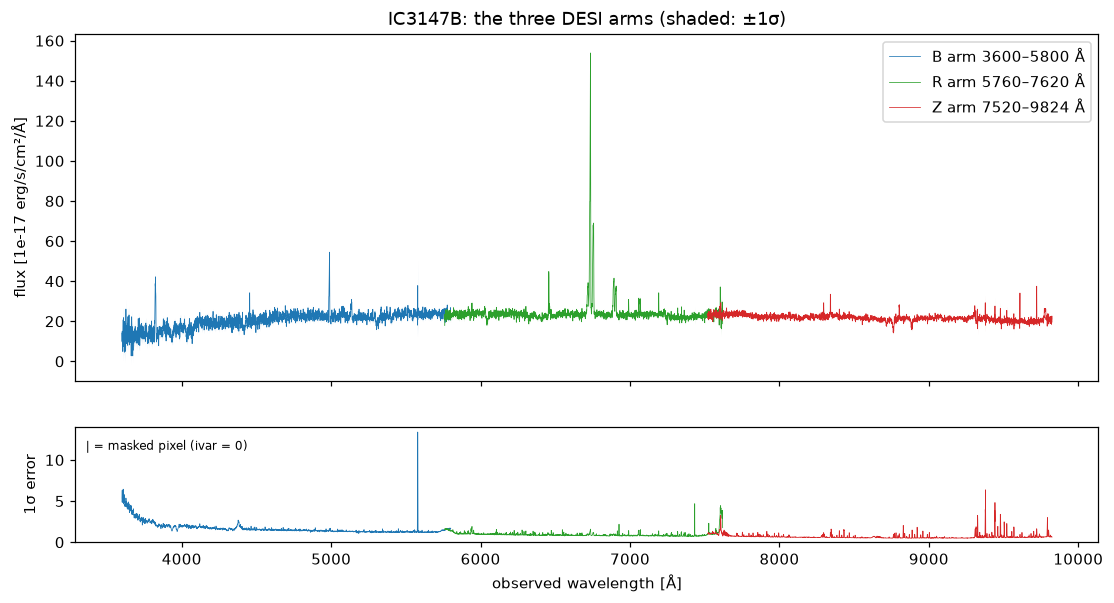

In [6]:
cand = inventory[(inventory.system == SYSTEM) & (inventory.role == "main")].sort_values("source")   # DESI before SDSS
SPEC = cand.index[0]; sp = inventory.loc[SPEC]; print("spectrum used below:", SPEC, f"({sp.source})")
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw=dict(height_ratios=[3, 1]))
if sp.source == "DESI":
    fmrow, arms = desi_row(sp.file, sp.spec_id)
    print(f"targetid {sp.spec_id}: {fmrow['COADD_NUMEXP']} exposures, {fmrow['COADD_EXPTIME']:.0f} s, {fmrow['COADD_NUMTILE']} tile(s)")
    for b, c in zip("BRZ", ("tab:blue", "tab:green", "tab:red")):
        a = arms[b]; ok = a["ivar"] > 0; err = np.where(ok, 1 / np.sqrt(np.where(ok, a["ivar"], 1)), np.nan)
        axs[0].plot(a["wave"], np.where(ok, a["flux"], np.nan), lw=0.5, color=c, label=f"{b} arm {a['wave'][0]:.0f}–{a['wave'][-1]:.0f} Å")
        axs[0].fill_between(a["wave"], a["flux"] - err, a["flux"] + err, color=c, alpha=0.2, lw=0)
        axs[1].plot(a["wave"], err, lw=0.5, color=c); axs[1].plot(a["wave"][a["mask"] > 0], np.zeros((a["mask"] > 0).sum()), "|", color="k", ms=8)
    wave = np.concatenate([arms[b]["wave"] for b in "BRZ"]); flux = np.concatenate([arms[b]["flux"] for b in "BRZ"]); ivar = np.concatenate([arms[b]["ivar"] for b in "BRZ"])
    o = np.argsort(wave); wave, flux, ivar = wave[o], flux[o], ivar[o]; sig_kms_inst = None; ttl = "the three DESI arms"
else:
    hdr, d, so = sdss_file(sp.file); c = {k.lower(): k for k in d.dtype.names}
    wave = 10 ** d[c["loglam"]]; flux = d[c["flux"]]; ivar = d[c["ivar"]]; ok = ivar > 0; err = np.where(ok, 1 / np.sqrt(np.where(ok, ivar, 1)), np.nan)
    print(f"plate {hdr['PLATEID']} mjd {hdr['MJD']} fiber {hdr['FIBERID']}: {hdr.get('NEXP', '?')} exposures, {hdr['EXPTIME']:.0f} s; pipeline z = {float(so['Z']):.5f} ({str(so['CLASS']).strip()})")
    axs[0].plot(wave, np.where(ok, flux, np.nan), lw=0.5, color="tab:orange", label=f"SDSS {wave[0]:.0f}–{wave[-1]:.0f} Å"); axs[0].fill_between(wave, flux - err, flux + err, color="tab:orange", alpha=0.2, lw=0)
    axs[1].plot(wave, err, lw=0.5, color="tab:orange"); axs[1].plot(wave[~ok], np.zeros((~ok).sum()), "|", color="k", ms=8)
    sig_kms_inst = d[c["wdisp"]] * C_KMS * np.log(10) * 1e-4; ttl = "the SDSS spectrum"
axs[0].set(ylabel="flux [1e-17 erg/s/cm²/Å]", title=f"{SPEC}: {ttl} (shaded: ±1σ)"); axs[0].legend()
axs[1].set(xlabel="observed wavelength [Å]", ylabel="1σ error", ylim=(0, None)); axs[1].text(0.01, 0.8, "| = masked pixel (ivar = 0)", transform=axs[1].transAxes, fontsize=8); plt.show()

## 1.6 Pixel scale

DESI's grid is linear, 0.8 Å per pixel: in velocity units, $c\,\Delta\lambda/\lambda$, 67 km/s at the
blue end and 24 km/s at the red end. SDSS's grid is logarithmic: a constant 69 km/s per pixel. A galaxy
line with $\sigma \approx 100$ km/s is sampled by only a few pixels — which is why the resolution, not
just the pixel size, matters.

pixel step: 0.80 Å (min 0.00, max 0.80); 35 km/s median


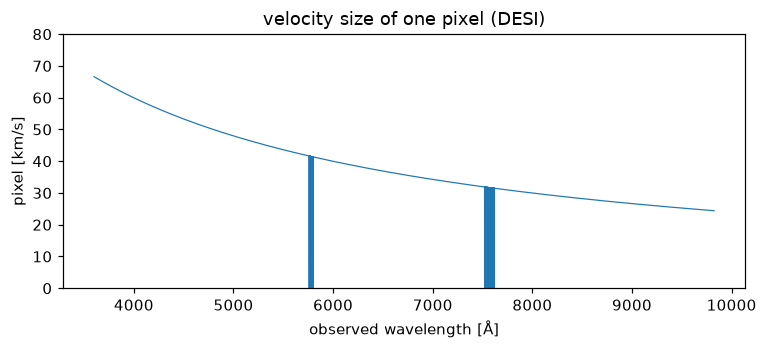

In [7]:
dlam = np.diff(wave); print(f"pixel step: {np.median(dlam):.2f} Å (min {dlam[dlam > 0].min():.2f}, max {dlam.max():.2f}); {np.median(C_KMS * dlam / wave[1:]):.0f} km/s median")
fig, ax = plt.subplots(figsize=(8, 3)); ax.plot(wave[1:], C_KMS * dlam / wave[1:], lw=0.8); ax.set(xlabel="observed wavelength [Å]", ylabel="pixel [km/s]", ylim=(0, 80), title=f"velocity size of one pixel ({sp.source})"); plt.show()

## 1.7 Spectral resolution

A perfectly narrow line is recorded as a blurred profile, the **line-spread function** (LSF). DESI stores
it explicitly: the `RESOLUTION` extension is a band matrix with 11 diagonals per pixel — the LSF centred
on that pixel, in units of pixels; we fit a Gaussian to it at several wavelengths. SDSS stores a
per-pixel `wdisp` (Gaussian σ in pixels of its log grid). Both are converted to the resolving power
$R = \lambda / {\rm FWHM}$ and to $\sigma_{\rm inst}$ in km/s. Whatever your spectrum is, both surveys
are drawn (the other one from a reference spectrum of the sample) so you can compare them.

arm   wave  sigma_pix  sigma_A       R  sigma_kms
  B 3640.0       0.80     0.64 2406.48      52.90
  B 4064.0       0.83     0.66 2602.81      48.91
  B 4488.0       0.81     0.65 2926.24      43.51
  B 4912.0       0.82     0.65 3187.51      39.94
  B 5336.0       0.81     0.65 3489.53      36.48
  B 5760.8       0.81     0.64 3794.33      33.55
  R 5800.0       0.82     0.65 3766.12      33.80
  R 6156.0       0.82     0.66 3990.98      31.90
  R 6512.0       0.82     0.65 4223.88      30.14
  R 6868.0       0.81     0.65 4509.94      28.23
  R 7224.0       0.81     0.64 4762.24      26.73
  R 7580.8       0.80     0.64 5059.69      25.16
  Z 7560.0       0.97     0.78 4116.56      30.93
  Z 8004.8       0.96     0.77 4438.38      28.68
  Z 8449.6       0.95     0.76 4743.30      26.84
  Z 8894.4       0.95     0.76 4993.17      25.50
  Z 9339.2       0.91     0.73 5441.48      23.40
  Z 9784.8       0.95     0.76 5441.73      23.40


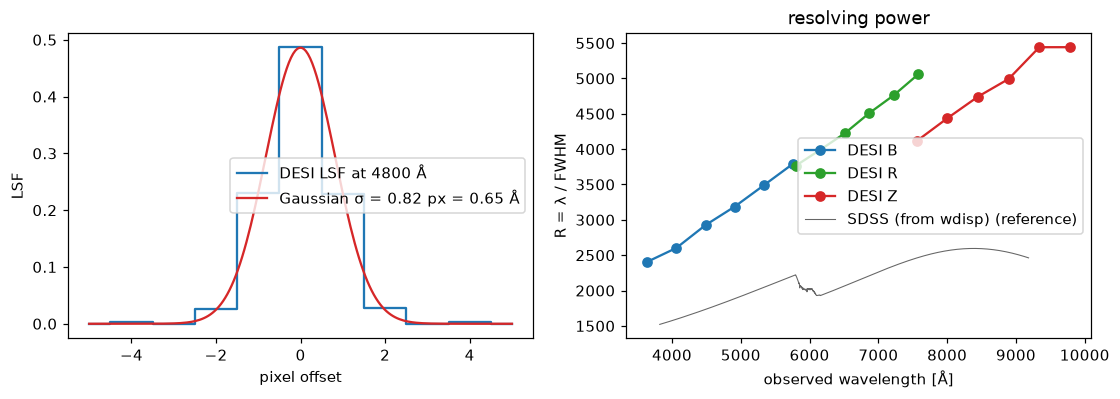

instrumental σ at Hα (6733 Å): DESI ≈ 29 km/s, SDSS ≈ 59 km/s


In [8]:
from scipy.optimize import curve_fit
g = lambda x, A, mu, s: A * np.exp(-0.5 * ((x - mu) / s) ** 2)
REF_DESI = inventory.loc["IC3147B"]; REF_SDSS = inventory.loc["IC3147B_comp_sdss"]           # reference spectra, always available
def desi_resolution(arms):
    rows = []
    for b in "BRZ":
        a = arms[b]; nd = a["res"].shape[0]; off = np.arange(nd) - nd // 2
        for j in np.linspace(50, len(a["wave"]) - 50, 6).astype(int):
            prof = a["res"][:, j]
            if prof.sum() < 0.5: continue
            (A, mu, s_), _ = curve_fit(g, off, prof, p0=[prof.max(), 0, 1.5]); dl = a["wave"][1] - a["wave"][0]; lam = a["wave"][j]
            rows.append(dict(arm=b, wave=lam, sigma_pix=abs(s_), sigma_A=abs(s_) * dl, R=lam / (2.3548 * abs(s_) * dl), sigma_kms=C_KMS * abs(s_) * dl / lam))
    return pd.DataFrame(rows)
arms_d = arms if sp.source == "DESI" else desi_row(REF_DESI.file, REF_DESI.spec_id)[1]
d_s = sdss_file(sp.file if sp.source == "SDSS" else REF_SDSS.file)[1]; c = {k.lower(): k for k in d_s.dtype.names}
lam_s = 10 ** d_s[c["loglam"]]; sig_s = d_s[c["wdisp"]] * C_KMS * np.log(10) * 1e-4
res = desi_resolution(arms_d); print(res.round(2).to_string(index=False))
fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
a = arms_d["B"]; j = 1500; off = np.arange(11) - 5
axs[0].step(off, a["res"][:, j], where="mid", label=f"DESI LSF at {a['wave'][j]:.0f} Å"); (A, mu, s_), _ = curve_fit(g, off, a["res"][:, j], p0=[0.5, 0, 1.5]); xx = np.linspace(-5, 5, 200)
axs[0].plot(xx, g(xx, A, mu, s_), color="tab:red", label=f"Gaussian σ = {abs(s_):.2f} px = {abs(s_) * 0.8:.2f} Å"); axs[0].set(xlabel="pixel offset", ylabel="LSF"); axs[0].legend()
for b, col in zip("BRZ", ("tab:blue", "tab:green", "tab:red")):
    sel = res.arm == b; axs[1].plot(res.wave[sel], res.R[sel], "o-", color=col, label=f"DESI {b}" + ("" if sp.source == "DESI" else " (reference)"))
axs[1].plot(lam_s, C_KMS / (2.3548 * sig_s), lw=0.7, color="0.4", label="SDSS (from wdisp)" + ("" if sp.source == "SDSS" else " (reference)"))
axs[1].set(xlabel="observed wavelength [Å]", ylabel="R = λ / FWHM", title="resolving power"); axs[1].legend(); plt.show()
print(f"instrumental σ at Hα ({6564.6 * (1 + z):.0f} Å): DESI ≈ {np.interp(6564.6 * (1 + z), res.wave, res.sigma_kms):.0f} km/s, SDSS ≈ {np.interp(6564.6 * (1 + z), lam_s, sig_s):.0f} km/s")

So DESI resolves velocities down to ~25–50 km/s (σ), SDSS ~60–65 km/s. Galaxy emission lines here are
100–150 km/s wide: resolved, but the instrument still contributes measurably, and the fitting code
(notebook 2) must include it — pPXF takes this FWHM(λ) as input.

## 1.8 Two spectra of your system

If your galaxy has both a DESI and an SDSS spectrum, they are overlaid (same units; different fibre,
coverage and resolution). Otherwise the main galaxy and its companion, or, failing that, the reference
pair of the sample.

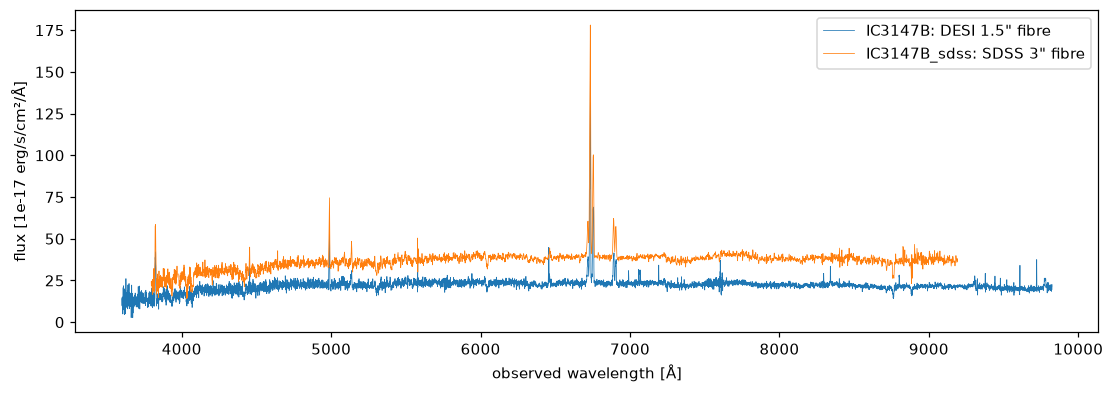

In [9]:
mine = inventory[inventory.system == SYSTEM]
def read_any(lab):
    sp_ = inventory.loc[lab]
    if sp_.source == "DESI":
        _, ar = desi_row(sp_.file, sp_.spec_id); w_ = np.concatenate([ar[b]["wave"] for b in "BRZ"]); f_ = np.concatenate([ar[b]["flux"] for b in "BRZ"]); i_ = np.concatenate([ar[b]["ivar"] for b in "BRZ"]); o_ = np.argsort(w_)
        return w_[o_], np.where(i_[o_] > 0, f_[o_], np.nan), f"{lab}: DESI 1.5\" fibre"
    d_ = sdss_file(sp_.file)[1]; c_ = {k.lower(): k for k in d_.dtype.names}
    return 10 ** d_[c_["loglam"]], np.where(d_[c_["ivar"]] > 0, d_[c_["flux"]], np.nan), f"{lab}: SDSS 3\" fibre"
mains = mine[mine.role == "main"]; comps = mine[mine.role == "comp"]
if mains.source.nunique() == 2: pick = list(mains.index)
elif len(comps): pick = [mains.index[0], comps.index[0]]
else: pick = ["IC3147B", "IC3147B_comp_sdss"]
fig, ax = plt.subplots(figsize=(12, 3.8))
for lab, col in zip(pick, ("tab:blue", "tab:orange")):
    w_, f_, l_ = read_any(lab); ax.plot(w_, f_, lw=0.5, color=col, label=l_)
ax.set(xlabel="observed wavelength [Å]", ylabel="flux [1e-17 erg/s/cm²/Å]"); ax.legend(); plt.show()

## Exercises

1. How far is each fibre from the catalogue centre of your galaxy? Is that within the fibre radius?
   (`MEAN_FIBER_RA/DEC` and `PLUG_RA/DEC` against `ra`, `dec` of the sample table.)
2. From the fibre-to-total flux ratio and the image, estimate what fraction of the *bar* the fibre covers.
3. The velocity size of a pixel and the LSF σ in pixels: at which wavelength does your spectrum sample the
   LSF most coarsely? Would you trust a line width of 30 km/s there?
4. DESI: look up the coadd `MASK` bit definitions (desispec `specmask`); SDSS: the `and_mask` bits
   (`sdss.org/dr17/algorithms/bitmasks`). Which bits are set in your spectrum, and would you exclude those pixels?
5. Query SDSS or DESI (section 1.3) 2′ around your galaxy instead of 30″: what else has a spectrum there,
   and at which redshifts?